In [15]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

import numpy as np

import scienceplots
plt.style.use('science')

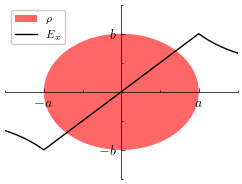

In [2]:
a=2
b=1.5
fig, axs = plt.subplots(1, figsize=(3, 3))
fig.hspace=0
e = Ellipse(xy=(0, 0), width=2*a, height=2*b, facecolor='red', alpha=0.6, label=r'$\rho$')

axs.add_patch(e)

axs.set_xticks([-a, a])
axs.set_yticks([-b, b])
axs.set_xticklabels([r'$-a$', r'$a$'], fontsize=12)
axs.set_yticklabels([r'$-b$', r'$b$'], fontsize=12)

axs.set_xlim(-1.5*a, 1.5*a)
axs.set_ylim(-1.5*b, 1.5*b)
axs.set_aspect('equal') # Crucial for circles/ellipses to look correcta


axs.spines['left'].set_position('center')
axs.spines['bottom'].set_position('center')
axs.spines['right'].set_visible(False)
axs.spines['top'].set_visible(False)

axs.xaxis.set_ticks_position('bottom')
axs.yaxis.set_ticks_position('left')

def E(x,E0):
    if x<-a or x>a:
        return E0/x
    else:
        return E0*x/a**2

x = np.linspace(-1.5*a, 1.5*a,1000)
y = [E(i,3) for i in x]
axs.plot(x, y, c='k', label=r'$E_x$')
#axs.legend()
axs.legend(loc='upper left', fontsize=8, frameon=True, framealpha=1)
plt.show()
fig.savefig('KV.pdf', bbox_inches='tight',)

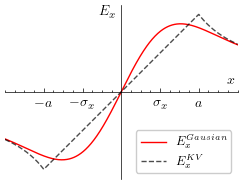

In [3]:
import PyBE.gaussian as g
import PyBE.uniform as u
# Parameters
sigma_x = 2.0
sigma_y = 1.5
x = np.linspace(-6, 6, 500)
y = np.linspace(-4.5, 4.5, 500)
X, Y = np.meshgrid(x, y)

Z = np.exp(-(X**2 / (2 * sigma_x**2) + Y**2 / (2 * sigma_y**2)))

fig, ax = plt.subplots(figsize=(3,3))

ax.set_xticks([-2*sigma_x, -sigma_x, sigma_x, 2*sigma_x])
ax.set_yticks([])
ax.set_xticklabels([r'$-a$', r'$-\sigma_x$', r'$\sigma_x$', r'$a$'], fontsize=12)

ax.set_xlim(-3*sigma_x, 3*sigma_x)
ax.set_ylim(-3*sigma_y, 3*sigma_y)
ax.set_aspect('equal') # Crucial for circles/ellipses to look correcta

ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

Ex, Ey = g.get_field(x,0,sigma_x,sigma_y)
Ex_u, Ey_u = [4*i for i in u.get_field(x,np.zeros_like(x),sigma_x*2,sigma_y*2)]

ax.plot(x,7*Ex, label=r'$E_x^{Gausian}$', c='r')
ax.plot(x,7*Ex_u, alpha=0.7, label=r'$E_x^{KV}$', c='k', ls='--')
ax.legend(loc='lower right', fontsize=9, frameon=True, framealpha=1)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$E_x$', rotation=0)
ax.yaxis.set_label_coords(0.44, 0.92)
ax.xaxis.set_label_coords(0.97, 0.6)
plt.show()
fig.savefig('gaussian_field.pdf', bbox_inches='tight',)

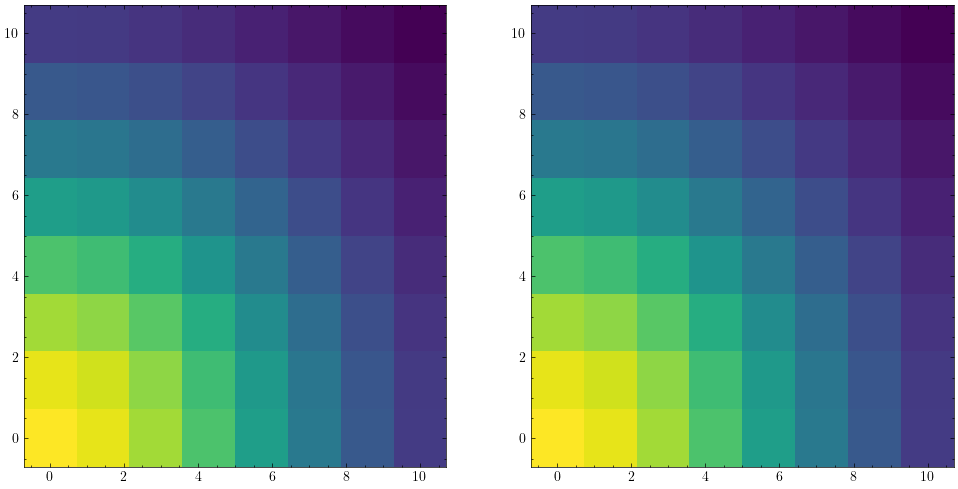

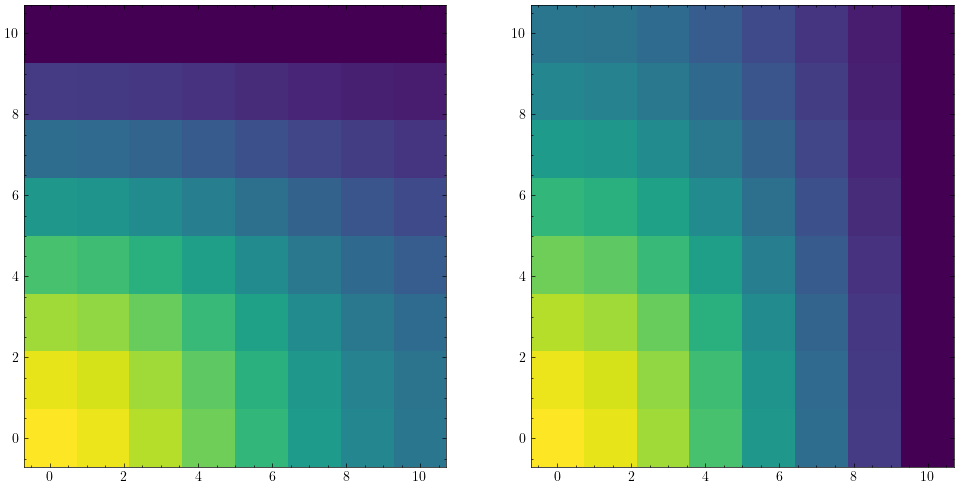

In [11]:
import numpy as np
import pipefields

x = np.linspace(0.01, 9.99, 8)
y = np.linspace(0.01, 9.99, 8)
XX, YY = np.meshgrid(x,y)

sigma_x = 4
sigma_y = 4

Ex_free, Ey_free = pipefields.freespace.get_field(XX, YY, 0.00, 0, sigma_x, sigma_y)
Ex_pipe, Ey_pipe = pipefields.rectangle.get_field(XX, YY, 0, 0, sigma_x, sigma_y, 20, 20)

for Ex, Ey in zip([Ex_free, Ex_pipe], [Ey_free, Ey_pipe]):
    dEx_dy, dEx_dx = np.gradient(Ex, 1, 1)
    dEy_dy, dEy_dx = np.gradient(Ey, 1, 1)
    fig, axs = plt.subplots(1,2, figsize=(12,6))
    axs[0].pcolormesh(XX, YY, Ex/XX)
    axs[1].pcolormesh(XX, YY, Ey/YY)

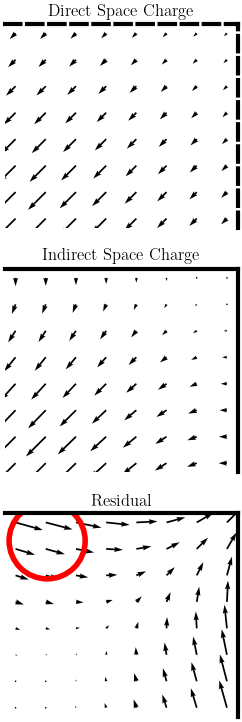

In [15]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, figsize=(3,9))
axs[0].quiver(XX, YY, -Ex_free/XX, -Ey_free/YY)
axs[1].quiver(XX, YY, -Ex_pipe/XX, -Ey_pipe/YY)
axs[2].quiver(XX, YY, -(Ex_pipe-Ex_free)/XX, -(Ey_pipe-Ey_free)/YY)

axs[0].set_title('Direct Space Charge')
axs[1].set_title('Indirect Space Charge')
axs[2].set_title('Residual')

for ax in axs:
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['top'].set_linewidth(3)
    ax.spines['right'].set_linewidth(3)

    
    ax.set_xticks([])
    ax.set_yticks([])

axs[0].spines['top'].set_linestyle('--')
axs[0].spines['right'].set_linestyle('--')
axs[2].scatter(1.5, 9.0, s=3000, edgecolors='r', facecolors='none', linewidth=4)
fig.savefig('field_quiver.pdf', bbox_inches='tight')

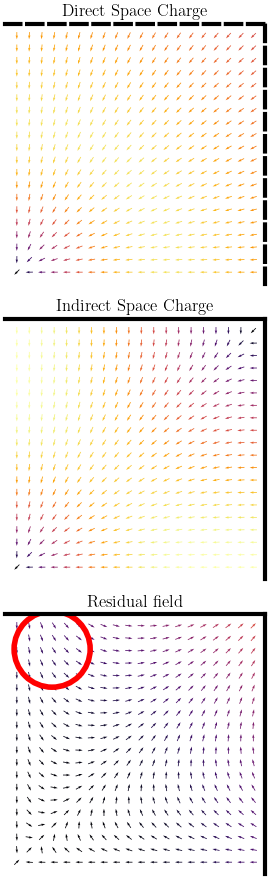

In [6]:
Ex_free, Ey_free = pipefields.freespace.get_field(XX, YY, 0.00, 0, sigma_x, sigma_y)
Ex_pipe, Ey_pipe = pipefields.rectangle.get_field(XX, YY, 0, 0, sigma_x, sigma_y, 20, 20)
grad_Ex_free = -Ex_free/XX
grad_Ex_pipe = -Ex_pipe/XX
grad_Ey_free = -Ex_free/YY
grad_Ey_pipe = -Ex_pipe/YY

def get_mag(u, v):
    return np.sqrt(u**2 + v**2)

mag0 = get_mag(grad_Ex_free, grad_Ey_free)
mag1 = get_mag(grad_Ex_pipe, grad_Ey_pipe)
mag2 = get_mag(Ex_pipe - Ex_free, Ey_pipe - Ey_free)

vmax = max(mag0.max(), mag1.max(), mag2.max())

fig, axs = plt.subplots(3, 1, figsize=(3, 9))
titles = ['Direct Space Charge', 'Indirect Space Charge', 'Residual field']
data = [(Ex_free, Ey_free, mag0), 
        (Ex_pipe, Ey_pipe, mag1), 
        (Ex_pipe-Ex_free, Ey_pipe-Ey_free, mag2)]

for i, (u, v, mag) in enumerate(data):
    q = axs[i].quiver(XX, YY, -u/mag, -v/mag, mag, cmap='inferno', pivot='mid')
    
    q.set_clim(vmin=0, vmax=vmax)
    
    axs[i].set_title(titles[i])
    axs[i].set_aspect('equal')
    

for ax in axs:
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['top'].set_linewidth(3)
    ax.spines['right'].set_linewidth(3)

    
    ax.set_xticks([])
    ax.set_yticks([])

axs[0].spines['top'].set_linestyle('--')
axs[0].spines['right'].set_linestyle('--')
axs[2].scatter(1.5, 9.0, s=3000, edgecolors='r', facecolors='none', linewidth=4)
plt.tight_layout()
plt.show()
fig.savefig('field_quiver.pdf', bbox_inches='tight')

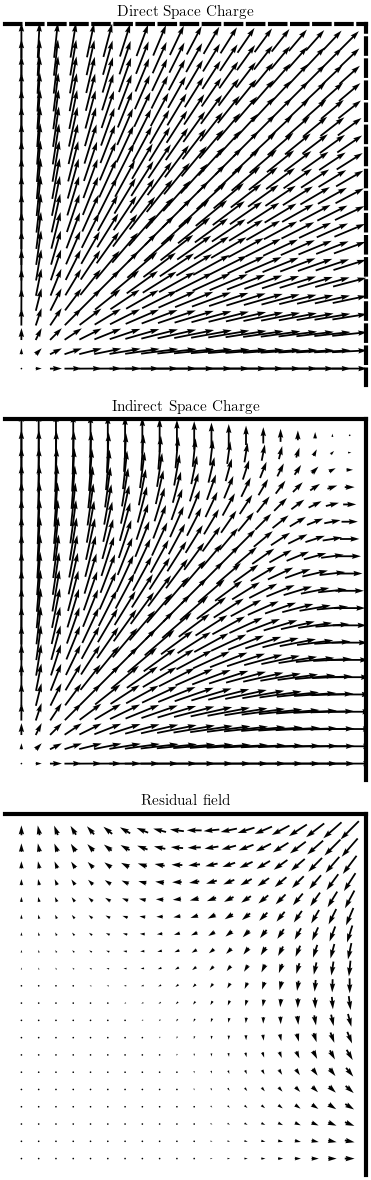

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# LaTeX rendering for publication quality
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})

def get_mag(u, v):
    return np.sqrt(u**2 + v**2)

# Calculate magnitudes
mag0 = get_mag(Ex_free, Ey_free)
mag1 = get_mag(Ex_pipe, Ey_pipe)
mag2 = get_mag(Ex_pipe - Ex_free, Ey_pipe - Ey_free)

# Find global max to define a consistent scale for all plots
vmax = max(mag0.max(), mag1.max(), mag2.max())

# Define a global scale: Higher number = shorter arrows.
# We scale relative to vmax to ensure the largest vector is a reasonable size.
global_scale = vmax * 8

fig, axs = plt.subplots(3, 1, figsize=(4, 12))
titles = ['Direct Space Charge', 'Indirect Space Charge', 'Residual field']
data = [(Ex_free, Ey_free), 
        (Ex_pipe, Ey_pipe), 
        (Ex_pipe - Ex_free, Ey_pipe - Ey_free)]

for i, (u, v) in enumerate(data):
    # scale_units='width' ensures arrows stay consistent relative to plot size
    q = axs[i].quiver(XX, YY, u, v, 
                      scale=global_scale, 
                      scale_units='width', 
                      pivot='mid', 
                      color='black',
                      width=0.005) # Adjust width for arrow "thickness"
    
    axs[i].set_title(titles[i], fontsize=11)
    axs[i].set_aspect('equal')
    
    # --- Spine and Frame Styling ---
    # Hide the standard left/bottom spines
    axs[i].spines['left'].set_visible(False)
    axs[i].spines['bottom'].set_visible(False)
    
    # Show and thicken the top/right spines
    axs[i].spines['top'].set_visible(True)
    axs[i].spines['right'].set_visible(True)
    axs[i].spines['top'].set_linewidth(3)
    axs[i].spines['right'].set_linewidth(3)
    
    # Remove ticks for a clean vector field view
    axs[i].set_xticks([])
    axs[i].set_yticks([])

# --- Special Styling for the first plot ---
axs[0].spines['top'].set_linestyle('--')
axs[0].spines['right'].set_linestyle('--')

# --- Add a reference key to the bottom plot ---
# This shows how long an arrow of a certain magnitude is
#axs[2].quiverkey(q, X=0.8, Y=0.05, U=vmax, 
#                 label=f'{vmax:.1e} V/m', labelpos='E', coordinates='axes')

plt.tight_layout()
plt.show()

# fig.savefig('field_quiver_standardized.pdf', bbox_inches='tight', dpi=300)

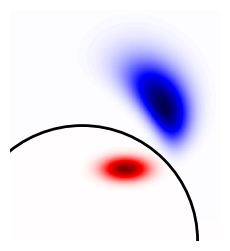

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Parameters
R = 8.0
x0 = 3
y0 = 5
sigma_x = 1
sigma_y = 0.5
threshold = 0.3  # Threshold for "solid" appearance

def rho_direct(z):
    x=z.real-x0
    y=z.imag-y0
    A=1
    rho = A*np.exp(-1/2*((x/sigma_x)**2 + (y/sigma_y)**2))

    mask = (x**2+y**2) > R**2
    rho[mask]=0
    return rho

def rho_indirect(z):
    z_image = R**2/z.conjugate()
    return -rho_direct(z_image)

x = np.linspace(-5, 1.2*R, 1000)
y = np.linspace(0, 2*R, 1000)
XX, YY = np.meshgrid(x, y)
ZZ = XX + 1j*YY

rho = rho_direct(ZZ) + rho_indirect(ZZ)

fig, ax = plt.subplots(figsize=(3, 3))
ax.pcolormesh(XX, YY, rho, cmap='seismic')
mesh = ax.pcolormesh(XX, YY, rho, cmap='seismic', vmin=-1, vmax=1, shading='auto', rasterized=True)
ax.set_aspect('equal')
# Draw the physical circle boundary
circle = plt.Circle((0, 0), R, color='black', fill=False, linewidth=2)
circle_arc = patches.Wedge((0, 0), R, 0, 90, facecolor='none', edgecolor='black', linewidth=2, zorder=3)
ax.add_patch(circle)
ax.set_axis_off()
ax.set_xlim(-5)
ax.set_ylim(0)
fig.savefig('image_charge.pdf', bbox_inches='tight')

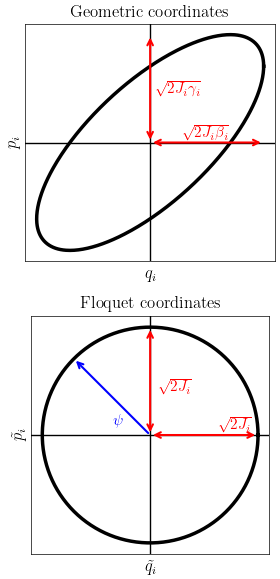

In [51]:
import numpy as np
import matplotlib.pyplot as plt

beta = 2.5
alpha = -1
gamma = (1 + alpha**2) / beta
epsilon = 1.0  # Emittance

phi = np.linspace(0, 2*np.pi, 500)
x = np.sqrt(epsilon * beta) * np.cos(phi)
px = -np.sqrt(epsilon / beta) * (alpha * np.cos(phi) - np.sin(phi))

fig, axs = plt.subplots(2, figsize=(3, 6))
axs[0].plot(x, px, c='k', lw=2.5, label=r'$\mathrm{Area} = 2\pi J$')

axs[0].axhline(0, color='black', lw=1)
axs[0].axvline(0, color='black', lw=1)

axs[0].annotate('', xy=(np.sqrt(epsilon*beta), 0), xytext=(0, 0),
             arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))

axs[0].text(np.sqrt(epsilon*beta)/2, 0.05, r'$\sqrt{2J_i\beta_i}$', 
         color='red', ha='center', fontsize=11)

axs[0].annotate('', xy=(0, np.sqrt(epsilon*gamma)), xytext=(0, 0),
             arrowprops=dict(arrowstyle='<->', color='r', lw=1.5))
axs[0].text(0.08, np.sqrt(epsilon*gamma)/2, r'$\sqrt{2J_i\gamma_i}$', 
         color='r', va='center', fontsize=11)

#axs[0].text(-np.sqrt(epsilon*beta), np.sqrt(epsilon*gamma), r'Tilt $\propto -\alpha$', 
#         fontsize=12, bbox=dict(facecolor='white', alpha=1))

axs[0].set_xlabel(r'$q_i$', fontsize=12)
axs[0].set_ylabel(r'$p_i$', fontsize=12)
axs[0].set_xticks([])
axs[0].set_yticks([])
axs[0].set_title(r'Geometric coordinates')
x_norm = x/np.sqrt(beta)
px_norm = (alpha*x + beta*px)/np.sqrt(beta)
axs[1].plot(x_norm, px_norm, color='k', lw=2.5, label=r'$\mathrm{Area} = 2\pi J$')

axs[1].annotate('', xy=(np.sqrt(epsilon), 0), xytext=(0, 0),
             arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))

axs[1].text(np.sqrt(epsilon*beta)/2, 0.05, r'$\sqrt{2J_i}$', 
         color='red', ha='center', fontsize=11)

axs[1].annotate('', xy=(0, np.sqrt(epsilon)), xytext=(0, 0),
             arrowprops=dict(arrowstyle='<->', color='r', lw=1.5))
axs[1].text(0.08, np.sqrt(epsilon*gamma)/2, r'$\sqrt{2J_i}$', 
         color='r', va='center', fontsize=11)

axs[1].annotate('', xy=(-np.sqrt(epsilon/2), np.sqrt(epsilon/2)), xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color='b', lw=1.5))
axs[1].text(-0.3,0.1, r'$\psi$', 
         color='b', ha='center', fontsize=11)

axs[1].axhline(0, color='black', lw=1)
axs[1].axvline(0, color='black', lw=1)
axs[1].set_aspect('equal')
axs[1].set_xlabel(r'$\tilde{q_i}$', fontsize=12)
axs[1].set_ylabel(r'$\tilde{p_i}$', fontsize=12)
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[1].set_title(r'Floquet coordinates')
fig.tight_layout()

fig.savefig('twiss_ellipse.pdf', bbox_inches='tight')

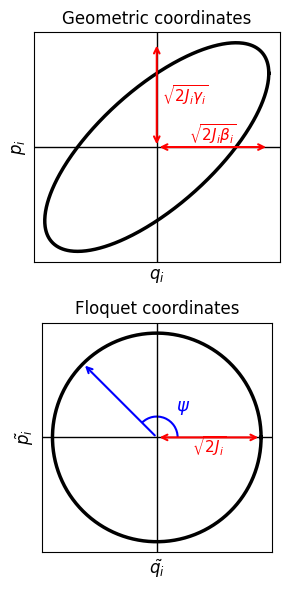

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

beta = 2.5
alpha = -1
gamma = (1 + alpha**2) / beta
epsilon = 1.0  # Emittance

phi = np.linspace(0, 2*np.pi, 500)
x = np.sqrt(epsilon * beta) * np.cos(phi)
px = -np.sqrt(epsilon / beta) * (alpha * np.cos(phi) - np.sin(phi))

fig, axs = plt.subplots(2, figsize=(3, 6))

# --- Top Plot: Geometric Coordinates ---
axs[0].plot(x, px, c='k', lw=2.5)
axs[0].axhline(0, color='black', lw=1)
axs[0].axvline(0, color='black', lw=1)

# Width annotation
axs[0].annotate('', xy=(np.sqrt(epsilon*beta), 0), xytext=(0, 0),
             arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))
axs[0].text(np.sqrt(epsilon*beta)/2, 0.05, r'$\sqrt{2J_i\beta_i}$', 
         color='red', ha='center', fontsize=11)

# Height annotation
axs[0].annotate('', xy=(0, np.sqrt(epsilon*gamma)), xytext=(0, 0),
             arrowprops=dict(arrowstyle='<->', color='r', lw=1.5))
axs[0].text(0.08, np.sqrt(epsilon*gamma)/2, r'$\sqrt{2J_i\gamma_i}$', 
         color='r', va='center', fontsize=11)

axs[0].set_xlabel(r'$q_i$', fontsize=12)
axs[0].set_ylabel(r'$p_i$', fontsize=12)
axs[0].set_xticks([]); axs[0].set_yticks([])
axs[0].set_title(r'Geometric coordinates')

# --- Bottom Plot: Floquet Coordinates ---
x_norm = x/np.sqrt(beta)
px_norm = (alpha*x + beta*px)/np.sqrt(beta)
axs[1].plot(x_norm, px_norm, color='k', lw=2.5)

# Radius annotation
axs[1].annotate('', xy=(np.sqrt(epsilon), 0), xytext=(0, 0),
             arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))
axs[1].text(np.sqrt(epsilon)/2, -0.15, r'$\sqrt{2J_i}$', 
         color='red', ha='center', fontsize=11)

# Angle Vector
angle_deg = 135 # 3pi/4
axs[1].annotate('', xy=(np.sqrt(epsilon)*np.cos(np.deg2rad(angle_deg)), 
                        np.sqrt(epsilon)*np.sin(np.deg2rad(angle_deg))), 
             xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color='b', lw=1.5))

# ADD THE ARC
# Arc(center, width, height, angle=0, theta1=0, theta2=360)
arc_radius = 0.4
arc = Arc((0, 0), arc_radius, arc_radius, angle=0, theta1=0, theta2=angle_deg, 
          color='b', lw=1.5)
axs[1].add_patch(arc)

# Angle Label
axs[1].text(0.25, 0.25, r'$\psi$', color='b', ha='center', fontsize=13)

axs[1].axhline(0, color='black', lw=1)
axs[1].axvline(0, color='black', lw=1)
axs[1].set_aspect('equal')
axs[1].set_xlabel(r'$\tilde{q_i}$', fontsize=12)
axs[1].set_ylabel(r'$\tilde{p_i}$', fontsize=12)
axs[1].set_xticks([]); axs[1].set_yticks([])
axs[1].set_title(r'Floquet coordinates')

fig.tight_layout()
plt.show()